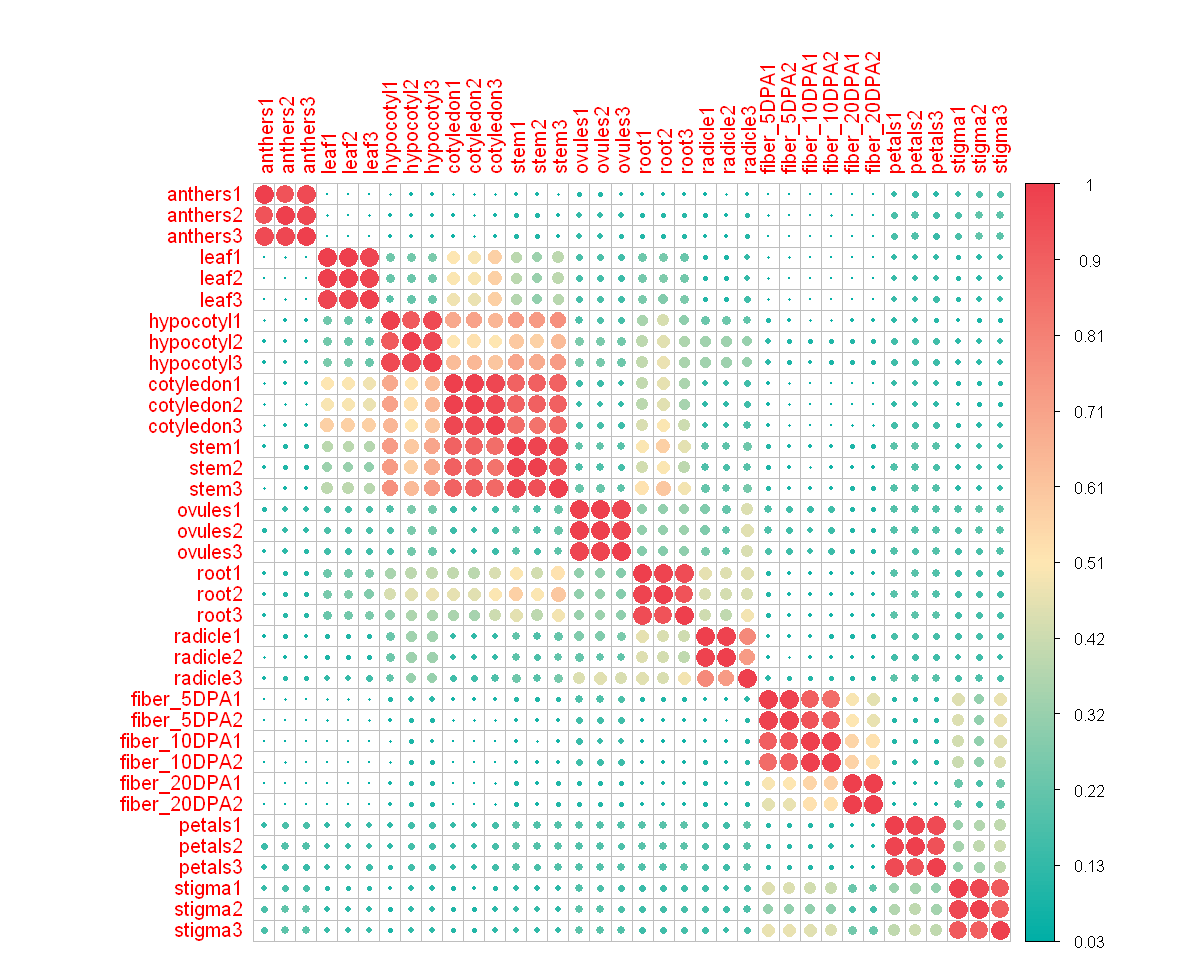

In [31]:
rm(list = ls())
options(repr.plot.width=10,repr.plot.height=8)
setwd('G:/Billfish/J668_multip_tissue_3D-genome/RNA_seq/PCA')
library(Hmisc)
library(corrplot)
library(pheatmap)
data <- read.csv('J668_all_tissue_TPM.txt', sep = '\t', header = T)
#data <- read.csv('J668_all_tissue_FPKM.txt', sep = '\t', header = T)
data_t <- data[,2:37]
res <- rcorr(as.matrix(data_t))
CorMatrix <- function(cor, p) {
  ut <- upper.tri(cor)
  data.frame(row = rownames(cor)[row(cor)[ut]],
             column = rownames(cor)[col(cor)[ut]],
             cor = (cor)[ut],
             p = p[ut])
}
RNA_CorMatrix <- CorMatrix(res$r, res$P)
p <- corrplot(res$r, col=colorRampPalette(c("#00AFA6","#FFE7B3","#ee3f4d"))(200), is.corr=FALSE)


In [35]:
pdf(file = "J668_all_tissue_TPM_coorplot.pdf")
options(repr.plot.width=8,repr.plot.height=8)
#p <- corrplot(res$r, order='hclust', addrect=14, rect.col = 'blue', col=colorRampPalette(c("#00AFA6","#FFE7B3","#ee3f4d"))(200), is.corr=FALSE, tl.col='black')
p <- corrplot(res$r, rect.col = 'blue', col=colorRampPalette(c("#00AFA6","#FFE7B3","#ee3f4d"))(200), is.corr=FALSE, tl.col='black')
dev.off()

png 
  2

Creating a temporary cluster...done:
主机'localhost'上15个节点的插座集群
Multiscale bootstrap... Done.


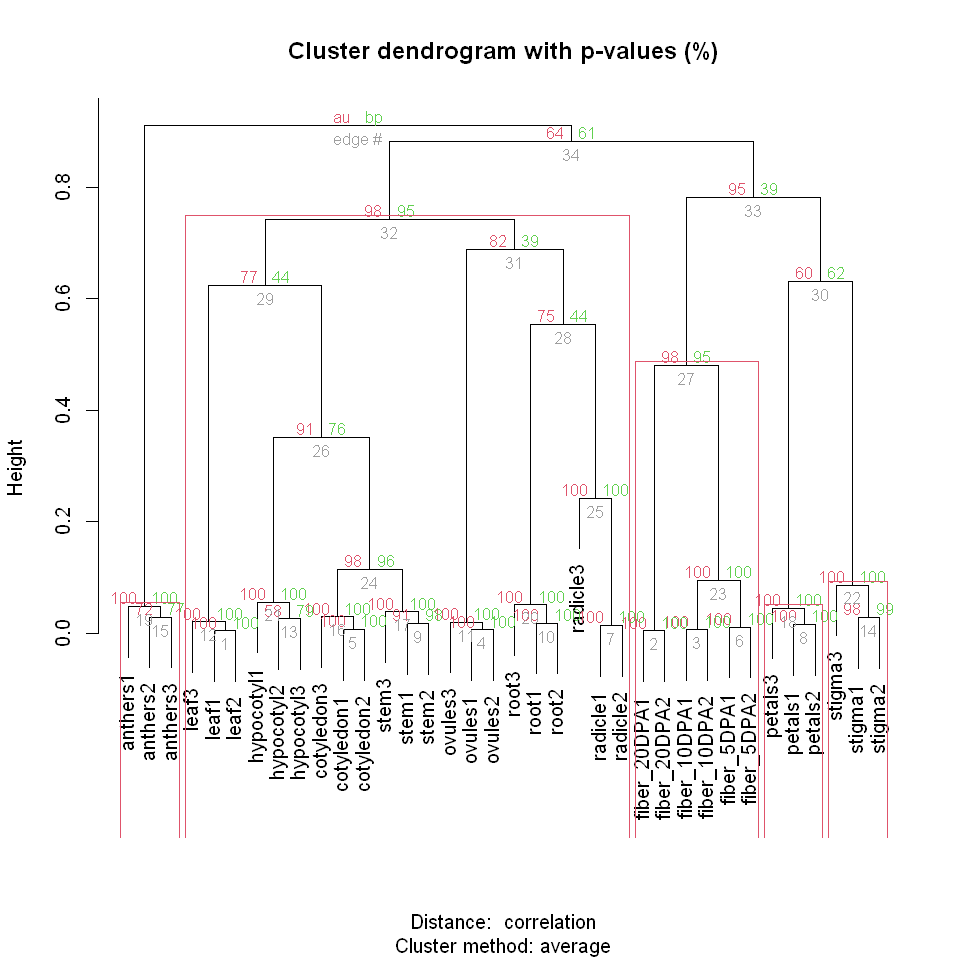

In [22]:
## pvclust
library(pvclust)
rm(list = ls())
setwd('G:/Billfish/J668_multip_tissue_3D-genome/RNA_seq/PCA')
data <- read.csv('J668_all_tissue_TPM.txt', sep = '\t', header = T, row.names = 1)
result <- pvclust(data, method.dist="cor", method.hclust="average", nboot=1000, parallel=TRUE)
plot(result)
pvrect(result, alpha=0.95)


In [29]:
pdf(file = "J668_all_tissue_TPM_pvclust.pdf")
options(repr.plot.width=10,repr.plot.height=8)
plot(result)
dev.off()

png 
  2